<a href="https://colab.research.google.com/github/Atharv-1905/Machine-Learning/blob/main/XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**XGBoost (Extreme Gradient Boosting)**



## 1. Theoretical Concept
XGBoost is a **Gradient Boosting Decision Tree (GBDT)** algorithm. Unlike Random Forest, which builds trees independently (Bagging), XGBoost builds trees **sequentially** (Boosting).

* **Core Idea:** It is an additive model. Each new tree $f_t(x)$ is added to fit the **residuals** (errors) of the previous prediction.
* **The Prediction:**
  $\hat{y}_i = \sum_{k=1}^{K} f_k(x_i)$

  Where $K$ is the total number of trees.



In [ ]:
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd



In [ ]:
# 1. LOAD DATA
# The "Hello World" of datasets
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# Split into Train (80%) and Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [ ]:
# 2. DEFINE THE MODEL
# We set specific hyperparameters to see how they work
model = XGBClassifier(
    n_estimators=100,       # Number of trees (boosting rounds)
    learning_rate=0.1,      # Step size (eta) - How much we correct the previous error
    max_depth=3,            # Shallow trees (weak learners) prevent overfitting
    reg_lambda=1,           # L2 Regularization term (Omega in the formula)
    objective='multi:softmax', # We have 3 flower types, so we use softmax
    num_class=3,
    eval_metric='mlogloss', # Monitor the Log Loss error
    use_label_encoder=False
)





## 2. Mathematical Derivation

The power of XGBoost lies in its unique Objective Function and how it uses **Taylor Expansion** to optimize it.

### Step 1: The Objective Function
We aim to minimize an objective function that consists of two parts: **Training Loss** ($L$) and **Regularization** ($\Omega$).

$$\text{Obj}(\theta) = \sum_{i=1}^{n} L(y_i, \hat{y}_i) + \sum_{k=1}^{K} \Omega(f_k)$$

* **$L$ (Loss):** Measures how well the model fits the data (e.g., MSE for regression, LogLoss for classification).
* **$\Omega$ (Regularization):** Penalizes complexity to prevent overfitting.
    $$\Omega(f) = \gamma T + \frac{1}{2} \lambda ||w||^2$$
    Where $T$ is the number of leaves and $w$ are the leaf weights.

### Step 2: Additive Training (The "Greedy" Approach)
At step $t$, we add a new tree $f_t(x)$. The prediction becomes $\hat{y}_i^{(t)} = \hat{y}_i^{(t-1)} + f_t(x_i)$.
The objective at step $t$ is:

$$\text{Obj}^{(t)} = \sum_{i=1}^{n} L(y_i, \hat{y}_i^{(t-1)} + f_t(x_i)) + \Omega(f_t) + \text{Constant}$$

### Step 3: Taylor Expansion (The Key Derivation)
To optimize this efficiently, XGBoost approximates the Loss function using a **Second-Order Taylor Expansion**:

$$f(x + \Delta x) \approx f(x) + f'(x)\Delta x + \frac{1}{2}f''(x)\Delta x^2$$

Applying this to our Loss function:
$$L(y_i, \hat{y}_i^{(t-1)} + f_t(x_i)) \approx L(y_i, \hat{y}_i^{(t-1)}) + g_i f_t(x_i) + \frac{1}{2} h_i f_t^2(x_i)$$

Where:
* $g_i = \partial_{\hat{y}} L(y_i, \hat{y}^{(t-1)})$ is the **Gradient** (1st Derivative).
* $h_i = \partial^2_{\hat{y}} L(y_i, \hat{y}^{(t-1)})$ is the **Hessian** (2nd Derivative).

Removing the constant terms (previous loss), the simplified objective is:

$$\text{Obj}^{(t)} \approx \sum_{i=1}^{n} [g_i f_t(x_i) + \frac{1}{2} h_i f_t^2(x_i)] + \Omega(f_t)$$

### Step 4: The Optimal Leaf Weight ($w^*$)
By solving the derivative of the simplified objective equal to zero, we find the optimal weight (score) for any specific leaf node $j$:

$$w_j^* = - \frac{\sum_{i \in I_j} g_i}{\sum_{i \in I_j} h_i + \lambda}$$

* *This explains why XGBoost is robust:* If gradients sum to zero, weight is zero. $\lambda$ prevents the weight from exploding (division by zero).

### Step 5: The Similarity Score & Gain
Using the optimal weight, we calculate the **Similarity Score** for a leaf:

$$\text{Score} = \frac{1}{2} \frac{(\sum g_i)^2}{\sum h_i + \lambda}$$

When deciding to split a node, XGBoost calculates the **Gain** (Information Gain) as:

$$\text{Gain} = \frac{1}{2} \left[ \frac{(\sum g_L)^2}{\sum h_L + \lambda} + \frac{(\sum g_R)^2}{\sum h_R + \lambda} - \frac{(\sum g_{root})^2}{\sum h_{root} + \lambda} \right] - \gamma$$

* If $Gain > 0$, the split reduces error more than the complexity penalty $\gamma$.
* If $Gain < 0$, we stop (Pruning).





In [ ]:
# 3. TRAIN (Fit)
# This is where the Gradient & Hessian calculations happen!

model.fit(X_train, y_train)



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:21:53] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None, num_class=3, ...)

In [ ]:
# 4. PREDICT & EVALUATE
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\n✅ Model Accuracy: {acc:.2%}")




✅ Model Accuracy: 100.00%


<Figure size 1000x500 with 0 Axes>

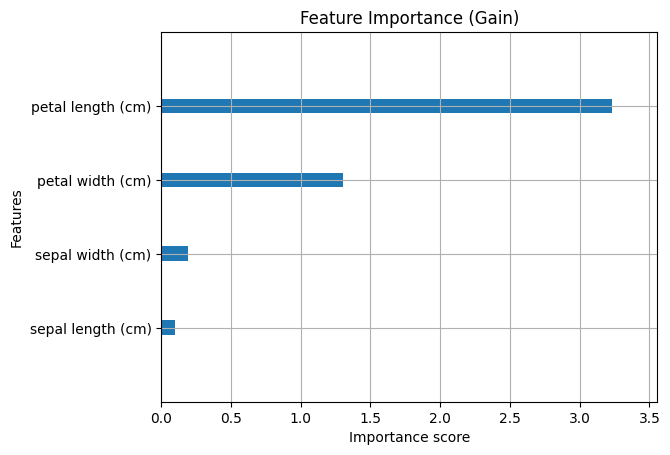

In [ ]:
# 5. VISUALIZE THE "BRAIN" 🧠
# Plot Feature Importance (Gain)
# This uses the 'Gain' formula we learned to see which feature was most useful.
plt.figure(figsize=(10, 5))
xgb.plot_importance(model, importance_type='gain', show_values=False, title='Feature Importance (Gain)')
plt.show()



## 3. Best Use Cases for XGBoost

1.  **Tabular Data:** It is the undisputed king of structured data (Excel/CSV/SQL tables).
2.  **Kaggle Competitions:** Historically wins a majority of competitions involving non-image/non-text data.
3.  **Complex Non-Linear Relationships:** When the relationship between features and target is not a straight line.
4.  **Handling Missing Values:** XGBoost learns the best direction to handle `NaN` values automatically; no imputation needed.
5.  **Feature Importance:** Excellent for understanding *which* variables drive the prediction.

**When NOT to use:**
* **Unstructured Data:** For Images (use CNNs) or pure Audio/Text (use Transformers/RNNs), though it works on text *features* (TF-IDF).
* **Tiny Datasets:** If you have <100 rows, it might overfit. Use Linear Regression or Naive Bayes instead.

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Figure size 2000x1000 with 0 Axes>

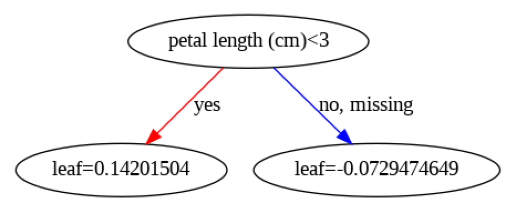

In [ ]:
# Bonus: Plot the FIRST tree in the ensemble
# You can see exactly how it makes the first decision.
plt.figure(figsize=(20, 10))
xgb.plot_tree(model, num_trees=0)
plt.show()

## Tuning

## XGBoost Hyperparameters & Significance

XGBoost is a highly flexible algorithm with many tuning parameters. Understanding these is critical for preventing overfitting and maximizing accuracy.

## 1. Primary Hyperparameters (The "Big Knobs")

### `n_estimators` (Number of Boosting Rounds)
* **Definition:** The number of decision trees to build sequentially.
* **Significance:**
    * **Too Low:** Underfitting (Model doesn't learn enough).
    * **Too High:** Overfitting (Model memorizes noise) + Slow training.
    * **Tuning Tip:** Often tuned in pair with `learning_rate`. Lower rates need more estimators.

### `learning_rate` (or `eta`)
* **Definition:** The step size shrinkage used to update weights. It prevents a single tree from dominating the prediction.
    * Formula update: $\hat{y}_{new} = \hat{y}_{old} + \eta \cdot f_t(x)$
* **Significance:**
    * **Lower ($\approx 0.01$):** Makes the model robust and accurate but requires more trees (slower).
    * **Higher ($\approx 0.3$):** Learns quickly but might overshoot the optimal solution.

### `max_depth`
* **Definition:** The maximum depth of a tree.
* **Significance:**
    * **Lower (3-6):** Conservative. Prevents the model from learning specific noise samples.
    * **Higher (10+):** Allows the model to learn complex, specific patterns (Risk of Overfitting).

---

## 2. Regularization Hyperparameters (The "Brakes")

These are unique to XGBoost compared to standard Gradient Boosting. They add penalty terms to the Loss Function.

### `reg_lambda` (L2 Regularization)
* **Definition:** Ridge regression equivalent. Penalizes large weights in the leaf nodes.
* **Significance:**
    * **Higher:** More conservative model (reduces variance/overfitting).
    * **Default:** 1.0 (some regularization is always on).

### `reg_alpha` (L1 Regularization)
* **Definition:** Lasso regression equivalent. Can force some weights to zero.
* **Significance:**
    * **Use Case:** Good for high-dimensional data where you suspect many features are useless (feature selection).

### `gamma` (Min Split Loss)
* **Definition:** The minimum loss reduction required to make a further partition on a leaf node.
* **Significance:**
    * Acts as a "pseudo-regularizer". If the Gain of a split is less than `gamma`, the tree won't split.
    * **Higher:** More conservative (Pruning).

---

## 3. Sampling Hyperparameters (Stochastic Boosting)

Inspired by Random Forest, these parameters add randomness to make the model robust.

### `subsample`
* **Definition:** The fraction of training data (rows) to sample for each boosting round.
* **Significance:**
    * **0.5:** Use 50% of random data for each tree.
    * **Effect:** Prevents overfitting. If set to 1.0, it uses all data (standard boosting).

### `colsample_bytree`
* **Definition:** The fraction of columns (features) to sample for each tree.
* **Significance:**
    * **Effect:** Similar to Random Forest's `max_features`. Essential if you have some very dominant features that overpower the rest.

---

### 🎛️ Key Hyperparameters

1.  **`n_estimators`**: Number of trees. Too high = Slow; Too low = Underfit.
2.  **`learning_rate` ($\eta$)**: Stepsize. Lower is more accurate but slower.
3.  **`max_depth`**: Tree height. Lower (3-6) prevents overfitting; Higher (10+) learns complex noise.
4.  **`reg_lambda` ($\lambda$)**: L2 Regularization. Higher = More conservative (fewer extreme weights).
5.  **`gamma` ($\gamma$)**: Minimum loss reduction required to split. Higher = More pruning.

In [ ]:
import pandas as pd
import xgboost as xgb
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score

# 1. Prepare Data
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Define Search Space
param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'max_depth': [3, 4, 5, 6, 8],
    'reg_alpha': [0, 0.1, 1],       # L1 Regularization
    'reg_lambda': [1, 10, 50],      # L2 Regularization
    'subsample': [0.6, 0.8, 1.0],   # % of rows used per tree
    'colsample_bytree': [0.6, 0.8, 1.0] # % of columns used per tree
}

# 3. Configure Random Search
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=20,           # Tries 20 random combinations
    cv=3,                # 3-fold cross-validation
    verbose=1,
    random_state=42,
    n_jobs=-1            # Use all CPU cores
)

# 4. Run Search
print("🚀 Searching for best parameters...")
random_search.fit(X_train, y_train)

# 5. Output Results
print("\n✅ Best Hyperparameters:")
print(random_search.best_params_)

print(f"\n🏆 Best Validation Accuracy: {random_search.best_score_:.2%}")

# 6. Final Test
best_model = random_search.best_estimator_
final_acc = accuracy_score(y_test, best_model.predict(X_test))
print(f"🧪 Final Test Accuracy: {final_acc:.2%}")

🚀 Searching for best parameters...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ Best Hyperparameters:
{'subsample': 1.0, 'reg_lambda': 10, 'reg_alpha': 1, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.6}

🏆 Best Validation Accuracy: 95.00%
🧪 Final Test Accuracy: 100.00%


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:26:10] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
